<a href="https://colab.research.google.com/github/force23airr/Option_trading/blob/main/2_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this session, we will look at the Python tools that we can use to characterize popular random distributions and calculate the associated statistics with these distributions.

First, we import all the needed libraries up front:

In [ ]:
import matplotlib.pyplot as plt
# What 'as' does is to use 'plt' as the short-cut representing 'matplotlib.pyplot'
# otherwise we'd have to type a lot

import pandas
import numpy
import scipy.stats

Now, let's draw some distributions using Python.

#### 1. Normal distribution

Recall that for the normal distribution
$$
X \sim \mathcal{N} (\mu, \sigma^2) \, ,
$$
the mean is $\mu$, and the standard deviation is $\sigma$.

In [ ]:
(mu, sigma) = (0.0, 1.0)
X = scipy.stats.norm(mu, sigma)

Now, $X$ is the random variable created according to the normal distribution we specified, just like the textbook version. It is a theoretical construct, not a data set. We can explore all the characterisitics related to this random variable.

For example, return the mean and the variance of $X$:

In [ ]:
X.mean()

In [ ]:
X.var()

(You can make changes to the mean and the variance of $X$ in the code above, and the returned values will of course change accordingly.)

Let's draw the probability density function (PDF) of $X$:

In [ ]:
fig, ax = plt.subplots()
# This line essentially says: give me an area to draw the figure;
# give me a set of axes with the figure;
# and I will define what the plot looks at as follows.

x_grid = numpy.linspace(-4, 4, 200)
ax.plot(x_grid, X.pdf(x_grid))
#X.pdf calculates the corresponding PDF values of 'x_grid'

ax.set_xlabel('x')
ax.set_ylabel('PDF of $X$')

plt.show()

In [ ]:
fig, ax = plt.subplots()
# This line essentially says: give me an area to draw the figure;
# give me a set of axes with the figure;
# and I will define what the plot looks at as follows.

x_grid = numpy.linspace(-4, 4, 200)
ax.plot(x_grid, X.cdf(x_grid))
#X.pdf calculates the corresponding PDF values of 'x_grid'

ax.set_xlabel('x')
ax.set_ylabel('CDF of $X$')

plt.show()

Now, let's see if we can easily calculate the mean and variance of a linear function of $X$.

#### 2. t distribution

In [ ]:
df = 5
X = scipy.stats.t(df)

(Notice that I reused the symbol $X$ to create a $t$-distribution random variable, so that I can reuse the bulk of the previous code. Below is literally the same code we used before.)

In [ ]:
X.mean(), X.var()

In [ ]:
fig, ax = plt.subplots()
# This line essentially says: give me an area to draw the figure;
# give me a set of axes with the figure;
# and I will define what the plot looks at as follows.

x_grid = numpy.linspace(-4, 4, 200)
ax.plot(x_grid, X.pdf(x_grid))
#X.pdf calculates the corresponding PDF values of 'x_grid'

ax.set_xlabel('x')
ax.set_ylabel('PDF of $X$')

plt.show()

In [ ]:
fig, ax = plt.subplots()
# This line essentially says: give me an area to draw the figure;
# give me a set of axes with the figure;
# and I will define what the plot looks at as follows.

x_grid = numpy.linspace(-4, 4, 200)
ax.plot(x_grid, X.cdf(x_grid))
#X.pdf calculates the corresponding PDF values of 'x_grid'

ax.set_xlabel('x')
ax.set_ylabel('CDF of $X$')

plt.show()

Of course, if you want to be fancy, you can supersede the plot of t distribution on top of the normal distribution plot. In this case, you'd have to use two symbols, say, $X$ for the normal distribution variable, and $Y$ for the t distribution variable. So the above code can be slightly modified to get this done:

In [ ]:
(mu, sigma) = (0.0, 1.0)
X = scipy.stats.norm(mu, sigma)

Y = scipy.stats.t(5)

fig, ax = plt.subplots()
x_grid = numpy.linspace(-4, 4, 200)

ax.plot(x_grid, X.pdf(x_grid), label='normal distribution')
#X.pdf calculates the corresponding PDF values of 'x_grid' for X
ax.plot(x_grid, Y.pdf(x_grid), label='t distribution')
#Y.pdf calculates the corresponding PDF values of 'x_grid' for Y
#

ax.set_xlabel('x')
ax.set_ylabel('PDF')

plt.legend() # To show the legends indicating which curve is which
plt.show()

#### 3. $\chi^2$ (Chi-squared) distribution

You only need to change the function name to `chi2`. And, since the PDF value for the $\chi^2$ distribution is zero for non-positive range, we plot the grids of $x$ starting from $0$.

In [ ]:
df = 5
X = scipy.stats.chi2(df)

fig, ax = plt.subplots()

x_grid = numpy.linspace(0, 20, 200)
ax.plot(x_grid, X.pdf(x_grid))

ax.set_xlabel('x')
ax.set_ylabel('PDF of $X$')

plt.show()

In [ ]:
df = 5
X = scipy.stats.chi2(df)

fig, ax = plt.subplots()

x_grid = numpy.linspace(0, 20, 200)
ax.plot(x_grid, X.cdf(x_grid))

ax.set_xlabel('x')
ax.set_ylabel('CDF of $X$')

plt.show()

Again, you can overlap $\chi^2$ distributions with different degrees of freedom to see how they change.

In [ ]:
X = scipy.stats.chi2(5)
Y = scipy.stats.chi2(10)

fig, ax = plt.subplots()
x_grid = numpy.linspace(0, 20, 200)

ax.plot(x_grid, X.pdf(x_grid), label='df=5')
#X.pdf calculates the corresponding PDF values of 'x_grid' for X
ax.plot(x_grid, Y.pdf(x_grid), label='df=10')
#Y.pdf calculates the corresponding PDF values of 'x_grid' for Y
#

ax.set_xlabel('x')
ax.set_ylabel('PDF')

plt.legend() # To show the legends indicating which curve is which
plt.show()

#### 4. F distribution

F distribution requires two degrees of freedom: the first corresponding to the degree of freedom for the numerator, second to that for the denominator.

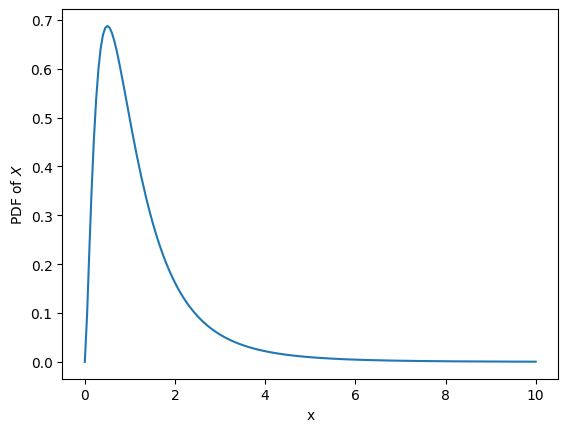

In [ ]:
df1 = 5
df2 = 10
X = scipy.stats.f(df1, df2)

fig, ax = plt.subplots()

x_grid = numpy.linspace(0, 10, 200)
ax.plot(x_grid, X.pdf(x_grid))

ax.set_xlabel('x')
ax.set_ylabel('PDF of $X$')

plt.show()

You can change the degrees of freedom for the $F$ distribution to see how the shape changes.

#### 5. Calculate probabilities of a distribution

To fix ideas, we ask, for a specific distribution underlying the random variable $X$, in the formula (remember that for the continuous distributions we numerate above, whether you include $X=a$ in the inequality or not does not matter)
$$
\Pr (X < a) = p \, , \tag{1}
$$
where $\Pr(\cdot)$ stands for the probability of whatever is described by $(\cdot)$:

1.   if $a$ is a known number, how much is $p$?
2.   if $p$ is a known number, how much is $a$?

Note that all of other forms of probabilities for a distribution can be cast as expressions of $(1)$:

*   $\Pr (X > a) = 1- \Pr (X < a) = 1-p \, ,$
*   $\Pr (a < X < b) = \Pr(X<b) - \Pr(X<a) = q - p \quad \text{if} \quad \Pr(X<b) \equiv q \, $.

Probabilities associated with the form $X < a$ is called the accumulative probability, or lower tail probability.

Say $X$ is a **normal distribution** random variable with the mean of $1$, and the variance of $4$ (thus the standard deviation of $2$):
$$
X \sim \mathcal{N} (1, 2^{2}) \, .
$$

What would be the value of $\Pr (X<2)$ (or $\Pr (X \le 2)$, because they are of the same value)?

Easy.

In [ ]:
a = 2
scipy.stats.norm.cdf(a, 1, 2)

np.float64(0.6914624612740131)

In [ ]:
scipy.stats.norm.cdf(-0.8, 0, 1)

np.float64(0.2118553985833967)

Now, let's turn it around. Say
$$
\Pr (X < a) = 0.6915 \, ,
$$
what is the value of $a$?

Again - easy.

In [ ]:
p = 0.6915
scipy.stats.norm.ppf(p, 1, 2)

np.float64(2.0002132543245534)

You can guess that, for other distributions, you basically only need to change the name of the distribution, and fill in the values of degrees of freedom if necessary.

Calculate $P(X<2)$ When $X$ is a **t distribution** random variable (let's say the degree of freedom is $10$):

In [ ]:
a = 2
df =10

scipy.stats.t.cdf(a, df)

np.float64(0.9633059826146297)

Calculate $a$ such that $\Pr (X<a)=0.9633$ for a t distribution with the degree of freedom equal to $10$:

In [ ]:
p = 0.9633
df =10

scipy.stats.t.ppf(p, df)

np.float64(1.99990216567127)

(Not exactly equal to $2$ due to rounding errors.)

Next, calculate $P(X<2)$ When $X$ is a **chi-squared** distribution random variable (with the degree of freedom is $10$):

In [ ]:
scipy.stats.chi2.cdf(2, 10)

np.float64(0.003659846827343713)

The reverse calculation is:

In [ ]:
scipy.stats.chi2.ppf(0.003660, 10)

np.float64(2.0000199852899536)

I will leave it as an exercise for you to calculate probabilities and critical values for F distributions.

In [ ]:
scipy.stats.f.ppf(0.8358, 5, 10)

np.float64(1.999968834365501)

In [ ]:
scipy.stats.f.cdf(2.0, 5, 10)

np.float64(0.8358050491002613)

Last, there is a logistic function that is not exactly a distribution. However, in view of the logistic regression we are going to learn near the end of this semester, it is better we know it right here how Python is calling it for calculations:
$$
f(x) = \frac{1}{1+ e^{-x}} \, .
$$

In Python, it is implemented by `expit` in the `scipy.special` library:

In [ ]:
from scipy.special import expit
print(expit(0))

In [ ]:
print(expit(1000))